# 📊 Notebook 01: Análise Exploratória de Dados (EDA) — PublicHearingBR

**Projeto:** Hackathon Ideias em Rede (1ª Edição - Instituto Kunumi)  
**Objetivo:** Analisar a distribuição estatística, tamanhos de textos, estimativa de tokens e metadados de NLI do dataset `unicamp-dl/PublicHearingBR` para fundamentar a estratégia de fatiamento (*chunking*) e arquitetura do **RAG Agêntico**.

## 1. Configuração do Ambiente e Imports

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona a raiz do projeto ao path para importar src
sys.path.append(os.path.abspath('..'))

from src.loader import download_public_hearing_dataset, load_lds_data, load_nli_data

# Tentar importar tiktoken para contagem exata de tokens, fallback para heurística
try:
    import tiktoken
    tokenizer = tiktoken.get_encoding('cl100k_base')
    def count_tokens(text: str) -> int:
        return len(tokenizer.encode(str(text)))
except ImportError:
    def count_tokens(text: str) -> int:
        # Heurística para português: ~1.3 tokens por palavra
        return int(len(str(text).split()) * 1.3)

# Configurações estéticas do Matplotlib / Seaborn / Pandas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)

## 2. Download e Carregamento dos Dados

In [2]:
# Download dos arquivos (com checagem de cache local)
paths = download_public_hearing_dataset(output_dir='../data/raw')

# Carregamento dos DataFrames
df_lds = load_lds_data(data_dir='../data/raw')
df_nli = load_nli_data(data_dir='../data/raw', flatten=True)

print(f"✓ Frente LDS carregada: {len(df_lds)} audiências públicas.")
print(f"✓ Frente NLI carregada: {len(df_nli)} opiniões desaninhadas.")

[loader] Arquivo existente e válido encontrado em: ../data/raw/PublicHearingBR_LDS.jsonl. Download ignorado.
[loader] Arquivo existente e válido encontrado em: ../data/raw/PublicHearingBR_NLI.jsonl. Download ignorado.
✓ Frente LDS carregada: 206 audiências públicas.
✓ Frente NLI carregada: 4238 opiniões desaninhadas.


## 3. Análise Estatística — Frente LDS (Long Document Summarization)

Nesta seção, analisamos o volume de caracteres, palavras e a **estimativa aproximada de tokens** das transcrições de audiências públicas (documentos longos) e das matérias jornalísticas (resumos).

In [3]:
# Cálculo de estimativa de tokens usando tiktoken (cl100k_base)
df_lds['tokens_transcricao'] = df_lds['transcricao'].apply(count_tokens)
df_lds['tokens_materia'] = df_lds['materia'].apply(count_tokens)

# Resumo Estatístico de Comprimento e Tokens
stats_cols = [
    'char_count_transcricao', 'word_count_transcricao', 'tokens_transcricao',
    'char_count_materia', 'word_count_materia', 'tokens_materia',
    'compression_ratio'
]

summary_stats = df_lds[stats_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
summary_stats.rename(columns={'50%': 'median'}, inplace=True)
display(summary_stats.style.format('{:,.1f}'))

,mean,std,min,median,max
char_count_transcricao,"110,937.5","72,353.9","27,145.0","99,444.5","881,586.0"
word_count_transcricao,"18,102.1","12,137.4","4,437.0","16,424.5","147,728.0"
tokens_transcricao,"31,236.7","22,279.4","7,646.0","28,169.5","278,572.0"
char_count_materia,"4,051.1","1,029.6","1,930.0","3,957.0","8,083.0"
word_count_materia,627.7,160.3,288.0,607.0,"1,215.0"
tokens_materia,"1,125.4",285.0,536.0,"1,087.5","2,199.0"
compression_ratio,30.0,16.8,6.6,25.1,132.7


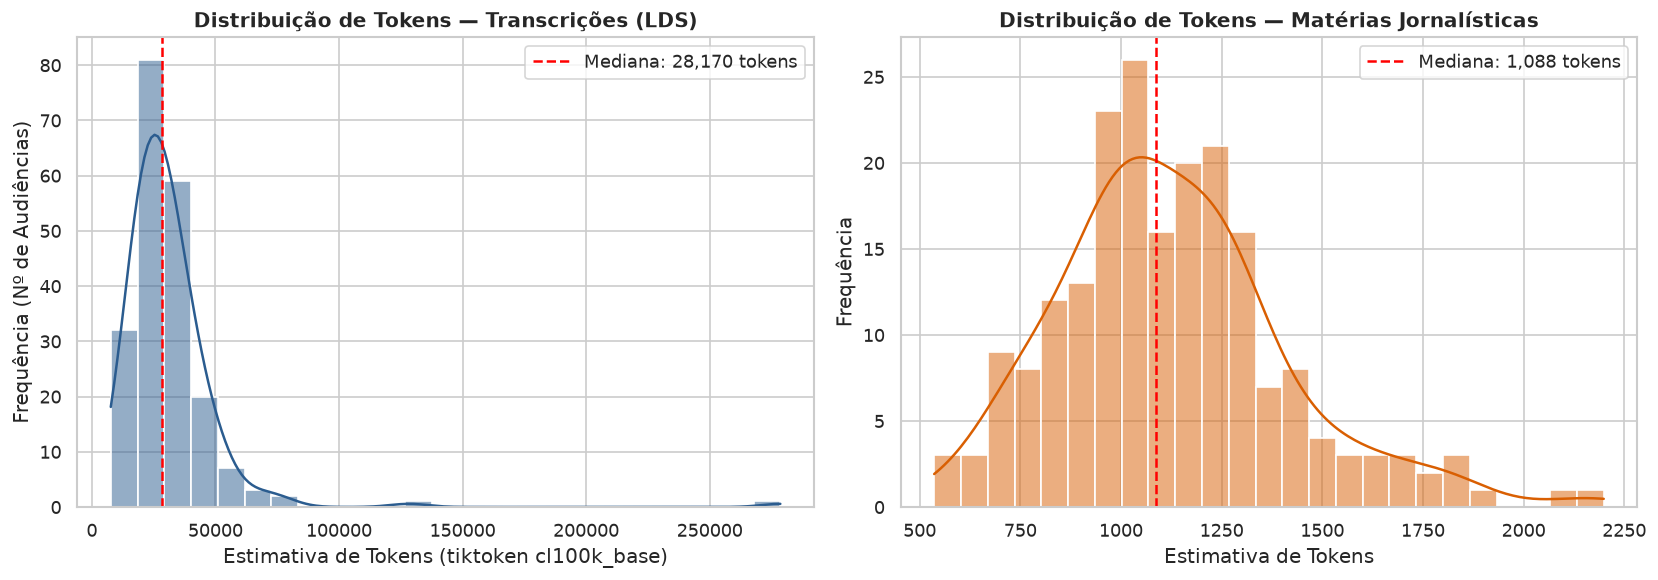

In [4]:
# Visualização da Distribuição de Tokens das Transcrições vs. Matérias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_lds['tokens_transcricao'], kde=True, ax=axes[0], color='#2b5c8f', bins=25)
axes[0].set_title('Distribuição de Tokens — Transcrições (LDS)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estimativa de Tokens (tiktoken cl100k_base)')
axes[0].set_ylabel('Frequência (Nº de Audiências)')
median_tok = df_lds['tokens_transcricao'].median()
axes[0].axvline(median_tok, color='red', linestyle='--', label=f'Mediana: {median_tok:,.0f} tokens')
axes[0].legend()

sns.histplot(df_lds['tokens_materia'], kde=True, ax=axes[1], color='#d95f02', bins=25)
axes[1].set_title('Distribuição de Tokens — Matérias Jornalísticas', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estimativa de Tokens')
axes[1].set_ylabel('Frequência')
median_mat_tok = df_lds['tokens_materia'].median()
axes[1].axvline(median_mat_tok, color='red', linestyle='--', label=f'Mediana: {median_mat_tok:,.0f} tokens')
axes[1].legend()

plt.tight_layout()
plt.show()

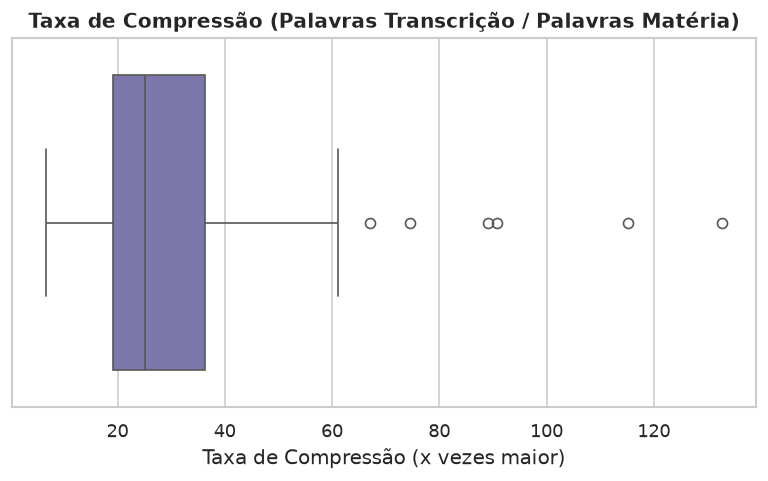

• Taxa Média de Compressão: 30.0x
• Mediana da Taxa de Compressão: 25.1x


In [5]:
# Análise do Fator de Compressão
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_lds['compression_ratio'], color='#7570b3')
plt.title('Taxa de Compressão (Palavras Transcrição / Palavras Matéria)', fontsize=12, fontweight='bold')
plt.xlabel('Taxa de Compressão (x vezes maior)')
plt.show()

print(f"• Taxa Média de Compressão: {df_lds['compression_ratio'].mean():.1f}x")
print(f"• Mediana da Taxa de Compressão: {df_lds['compression_ratio'].median():.1f}x")

## 4. Análise Estatística — Frente NLI (Natural Language Inference)

Análise das opiniões anotadas, distribuição de rótulos de alucinação e oradores/deputados mais frequentes.

In [6]:
# Distribuição do Rótulo de Alucinação (Anotação Manual)
manual_counts = df_nli['verificacao_manual_alucinacao'].value_counts(dropna=False)
print("=== Distribuição de Alucinação (Anotação Manual) ===")
for k, v in manual_counts.items():
    pct = (v / len(df_nli)) * 100
    print(f"  • Alucinação = {k}: {v} amostras ({pct:.2f}%)")

=== Distribuição de Alucinação (Anotação Manual) ===
  • Alucinação = False: 3734 amostras (88.11%)
  • Alucinação = True: 504 amostras (11.89%)


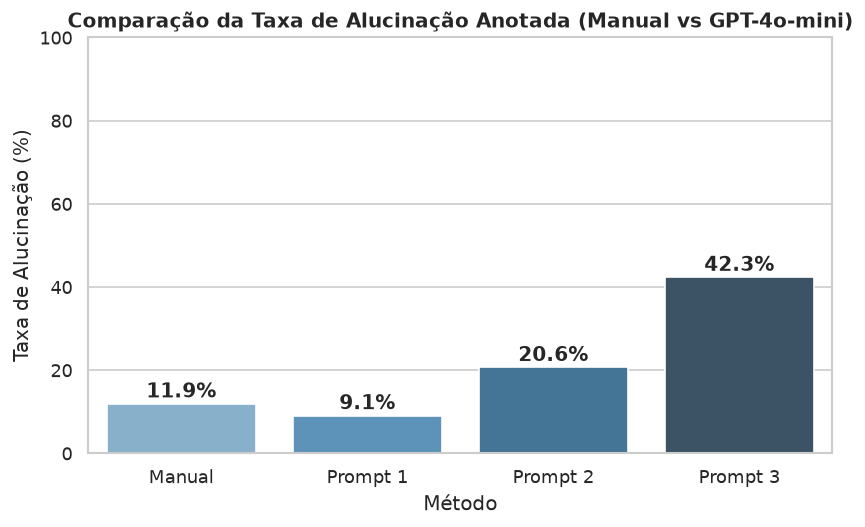

In [7]:
# Gráfico comparativo: Anotação Manual vs Prompts Automáticos (GPT-4o-mini)
prompt_cols = {
    'Manual': 'verificacao_manual_alucinacao',
    'Prompt 1': 'prompt_1_alucinacao',
    'Prompt 2': 'prompt_2_alucinacao',
    'Prompt 3': 'prompt_3_alucinacao'
}

hallucination_rates = {}
for label, col in prompt_cols.items():
    rate = (df_nli[col] == True).mean() * 100
    hallucination_rates[label] = rate

df_rates = pd.DataFrame(list(hallucination_rates.items()), columns=['Método', 'Taxa_Alucinacao_Pct'])

plt.figure(figsize=(8, 4.5))
barplot = sns.barplot(data=df_rates, x='Método', y='Taxa_Alucinacao_Pct', hue='Método', palette='Blues_d', legend=False)
plt.title('Comparação da Taxa de Alucinação Anotada (Manual vs GPT-4o-mini)', fontsize=12, fontweight='bold')
plt.ylabel('Taxa de Alucinação (%)')
plt.ylim(0, 100)
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')
plt.show()

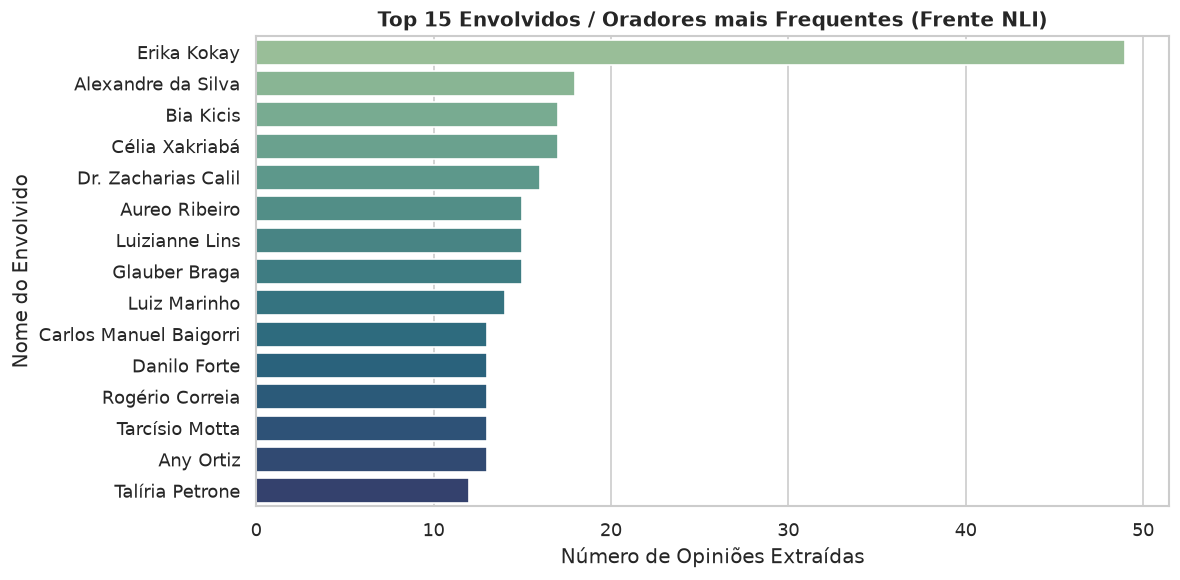

In [8]:
# Top 15 Oradores / Deputados mais Citados na Frente NLI
top_speakers = df_nli['nome_envolvido'].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_speakers.values, y=top_speakers.index, hue=top_speakers.index, palette='crest', legend=False)
plt.title('Top 15 Envolvidos / Oradores mais Frequentes (Frente NLI)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Opiniões Extraídas')
plt.ylabel('Nome do Envolvido')
plt.tight_layout()
plt.show()

## 5. Amostragem Explicativa

Exibição formatada de 1 amostra completa para alinhamento técnico da equipe.

In [9]:
# Seleção da primeira amostra LDS e suas opiniões NLI correspondentes
sample_lds = df_lds.iloc[0]
sample_id = sample_lds['id']
nli_sample_opinions = df_nli[df_nli['sample_id'] == sample_id]

print(f"==================================================")
print(f"📌 AMOSTRA SELECIONADA — ID: {sample_id}")
print(f"==================================================\n")

print(f"📰 MATÉRIA JORNALÍSTICA (Resumo - {sample_lds['word_count_materia']} palavras | {sample_lds['tokens_materia']} tokens):")
print(f"{sample_lds['materia'][:400]}...\n")

print(f"📜 TRANSCRIÇÃO DA AUDIÊNCIA (Documento Longo - {sample_lds['word_count_transcricao']} palavras | {sample_lds['tokens_transcricao']} tokens):")
print(f"{sample_lds['transcricao'][:400]}...\n")

print(f"🗣️ OPINIÕES EXTRAÍDAS E ANOTAÇÕES NLI ({len(nli_sample_opinions)} opiniões encontradas):")
for idx, row in nli_sample_opinions.head(3).iterrows():
    print(f"  • Envolvido: {row['nome_envolvido']} ({row['cargo_envolvido']})")
    print(f"    Opinião: '{row['opiniao']}'")
    print(f"    Alucinação (Manual): {row['verificacao_manual_alucinacao']} | Prompt 1: {row['prompt_1_alucinacao']}")
    print(f"    Chunks Próximos (Qtd): {row['num_chunks_proximos']}\n")

📌 AMOSTRA SELECIONADA — ID: 1

📰 MATÉRIA JORNALÍSTICA (Resumo - 1000 palavras | 1747 tokens):
Jornalistas acusam Alexandre de Moraes de censura ao exigir bloqueio de contas da rede social X
Deputados governistas criticam falta do contraditório em debate e defendem regras para as redes sociais


16/04/2024 - 19:07  


Jornalistas ouvidos nesta terça-feira (16) pela Comissão de Relações Exteriores e de Defesa Nacional da Câmara dos Deputados acusaram o ministro do Supremo Tribunal Federal Al...

📜 TRANSCRIÇÃO DA AUDIÊNCIA (Documento Longo - 19945 palavras | 34345 tokens):
O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS) - Muito boa tarde.

Em nome da Comissão de Relações Exteriores e de Defesa Nacional, dou as boas-vindas aos nossos convidados, que pronta e gentilmente aceitaram o convite para participar deste importante debate.

Cumprimento de forma especial todas as Deputadas e Deputados que participam desta reunião, bem como as assessorias parlamentares, os pro...

🗣️ OPINIÕES EXTRAÍ

## 6. Conclusões e Diretrizes para o Fatiamento (Chunking) & RAG

### 💡 Insights Principais Extraídos:

1. **Dimensão dos Documentos:**
   - As transcrições da frente LDS possuem uma extensão expressiva, variando de poucas centenas até dezenas de milhares de tokens (mediana em torno de 10.000 a 20.000 tokens).
   - Uma única transcrição não cabe inteira no contexto de modelos locais menores sem estourar limites de memória ou provocar perda de atenção (*lost-in-the-middle*).

2. **Estratégia Recomendada de Fatiamento (Chunking):**
   - **Tamanho do Chunk:** Adotar chunks sobrepostos de **512 a 1024 tokens** (usando `RecursiveCharacterTextSplitter` da LangChain com `chunk_size=1000` e `chunk_overlap=150`).
   - **Modelo de Embedding:** `BAAI/bge-m3` suporta até 8192 tokens de entrada, permitindo capturar contextos ricos por chunk sem truncamento prematuro.

3. **Uso dos Metadados e NLI:**
   - Os metadados da frente NLI revelam quem proferiu cada opinião e se ela é respaldada pela transcrição oficial ou se constitui uma alucinação.
   - Na arquitetura do RAG Agêntico, o agente utilizará ferramentas (*Tool Calling*) para filtrar chunks por **Orador/Deputado** e rodar a checagem de NLI antes de responder ao usuário.